In [1]:
import matplotlib.pyplot as plt
import polars as pl

In [12]:
scores = pl.read_csv("rules_with_scores.csv")

scores.head(5)

biorxiv_doi,published_doi,title,flesch_reading_ease,flesch_kincaid_grade,gunning_fog,num_contractions,contractions_per_1000,uses_contractions,num_exclamation,exclamation_per_1000,uses_exclamation,num_signposting,signposting_per_1000,uses_signposting,num_vague_verbs,vague_verbs_per_1000,uses_vague_verbs,num_allows_to,allows_to_per_1000,uses_allows_to,num_aim_to,aim_to_per_1000,uses_aim_to,num_we,we_per_1000,uses_we,num_hedging,hedging_per_1000,uses_hedging,num_to_that_end,to_that_end_per_1000,uses_to_that_end,num_chatgpt_words,chatgpt_words_per_1000,uses_chatgpt_words,num_absolute_words,absolute_words_per_1000,uses_absolute_words,num_comparatives,comparatives_per_1000,uses_comparatives,num_passive,passive_per_1000,uses_passive
str,str,str,f64,f64,f64,i64,f64,bool,i64,f64,bool,i64,f64,bool,i64,f64,bool,i64,f64,bool,i64,f64,bool,i64,f64,bool,i64,f64,bool,i64,f64,bool,i64,f64,bool,i64,f64,bool,i64,f64,bool,i64,f64,bool
"""10.1101/004473""",null,"""The Invariance Hypothesis Impl…",36.883717,12.74376,15.653347,0,0.0,false,0,0.0,false,1,0.088168,true,17,1.498854,true,0,0.0,false,0,0.0,false,86,7.582437,true,81,7.141598,true,0,0.0,false,0,0.0,false,13,1.146182,true,18,1.587022,true,151,13.313349,true
"""10.1101/005660""",null,"""Practopoiesis: Or how life fos…",32.815371,13.824895,16.630765,0,0.0,false,1,0.063223,true,0,0.0,false,44,2.781817,true,0,0.0,false,0,0.0,false,15,0.948347,true,218,13.782639,true,0,0.0,false,0,0.0,false,20,1.264462,true,73,4.615287,true,214,13.529746,true
"""10.1101/006346""",null,"""NBLAST: Rapid, sensitive compa…",37.427088,12.909772,15.773101,0,0.0,false,0,0.0,false,0,0.0,false,28,3.028992,true,0,0.0,false,0,0.0,false,116,12.54868,true,49,5.300736,true,0,0.0,false,2,0.216357,true,2,0.216357,true,9,0.973605,true,100,10.817828,true
"""10.1101/006353""",null,"""The natverse: a versatile comp…",40.360756,11.923344,14.382643,0,0.0,false,1,0.10686,true,1,0.10686,true,53,5.663603,true,0,0.0,false,2,0.213721,true,76,8.121393,true,105,11.220346,true,0,0.0,false,1,0.10686,true,2,0.213721,true,12,1.282325,true,100,10.686044,true
"""10.1101/009936""",null,"""Fixed versus mixed RSA: Explai…",34.432053,13.260572,15.843166,0,0.0,false,0,0.0,false,0,0.0,false,30,4.13679,true,0,0.0,false,0,0.0,false,70,9.65251,true,37,5.102041,true,0,0.0,false,0,0.0,false,0,0.0,false,34,4.688362,true,58,7.997794,true


In [10]:
data = pl.read_csv("output/final_dataset.csv",separator=";")
data

word_count,sentence_count,flesch_reading_ease,gunning_fog,flesch_kincaid_grade,avg_sentence_length,avg_letter_per_word,lexicon_count,figure_count,table_count,section_count,reference_count,doi,preprint_date,preprint_category,published_doi,published_flag,citation_count,influential_citation_count,semantic_year,semantic_journal,status
i64,i64,f64,f64,f64,f64,f64,i64,i64,i64,f64,f64,str,str,str,str,i64,f64,f64,f64,str,i64
11342,605,36.883717,15.653347,12.74376,18.633058,5.21618,11273,15,3,34.0,121.0,"""10.1101/004473""","""2014-04-23""","""Neuroscience""",null,0,35.0,1.0,2014.0,"""PLoS Computational Biology""",200
9244,470,37.427088,15.773101,12.909772,19.606383,5.355507,9215,14,2,37.0,83.0,"""10.1101/006346""","""2014-08-08""","""Neuroscience""",null,0,260.0,33.0,2016.0,"""Neuron""",200
9358,541,40.360756,14.382643,11.923344,17.28281,5.336364,9350,8,2,33.0,142.0,"""10.1101/006353""","""2014-06-19""","""Neuroscience""",null,0,28.0,1.0,2014.0,"""bioRxiv""",200
1699,97,30.83227,16.599423,13.25383,17.28866,5.400716,1677,17,0,20.0,34.0,"""10.1101/011320""","""2014-11-11""","""Neuroscience""",null,0,23.0,3.0,2014.0,"""bioRxiv""",200
5630,250,29.091279,17.831729,14.781368,22.46,5.416563,5615,7,0,21.0,41.0,"""10.1101/013730""","""2015-01-30""","""Neuroscience""",null,0,0.0,0.0,2015.0,"""bioRxiv""",200
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
6320,311,27.515594,17.769865,14.40439,20.057878,5.51058,6238,4,3,28.0,57.0,"""10.1101/867689""","""2019-12-06""","""Neuroscience""",null,0,21.0,1.0,2019.0,"""Neuroimage""",200
13695,843,37.083819,15.228932,12.116538,16.220641,5.286164,13674,5,0,38.0,81.0,"""10.1101/868406""","""2019-12-06""","""Neuroscience""",null,0,67.0,5.0,2019.0,"""bioRxiv""",200
3743,224,29.019161,15.588259,13.358486,16.691964,5.55924,3739,2,3,20.0,30.0,"""10.1101/868414""","""2019-12-07""","""Neuroscience""",null,0,27.0,1.0,2019.0,"""Journal of child psychology an…",200


In [14]:
joined_df = data.join(scores, left_on="doi", right_on="biorxiv_doi", how="left")

joined_df

word_count,sentence_count,flesch_reading_ease,gunning_fog,flesch_kincaid_grade,avg_sentence_length,avg_letter_per_word,lexicon_count,figure_count,table_count,section_count,reference_count,doi,preprint_date,preprint_category,published_doi,published_flag,citation_count,influential_citation_count,semantic_year,semantic_journal,status,published_doi_right,title,flesch_reading_ease_right,flesch_kincaid_grade_right,gunning_fog_right,num_contractions,contractions_per_1000,uses_contractions,num_exclamation,exclamation_per_1000,uses_exclamation,num_signposting,signposting_per_1000,uses_signposting,num_vague_verbs,vague_verbs_per_1000,uses_vague_verbs,num_allows_to,allows_to_per_1000,uses_allows_to,num_aim_to,aim_to_per_1000,uses_aim_to,num_we,we_per_1000,uses_we,num_hedging,hedging_per_1000,uses_hedging,num_to_that_end,to_that_end_per_1000,uses_to_that_end,num_chatgpt_words,chatgpt_words_per_1000,uses_chatgpt_words,num_absolute_words,absolute_words_per_1000,uses_absolute_words,num_comparatives,comparatives_per_1000,uses_comparatives,num_passive,passive_per_1000,uses_passive
i64,i64,f64,f64,f64,f64,f64,i64,i64,i64,f64,f64,str,str,str,str,i64,f64,f64,f64,str,i64,str,str,f64,f64,f64,i64,f64,bool,i64,f64,bool,i64,f64,bool,i64,f64,bool,i64,f64,bool,i64,f64,bool,i64,f64,bool,i64,f64,bool,i64,f64,bool,i64,f64,bool,i64,f64,bool,i64,f64,bool,i64,f64,bool
11342,605,36.883717,15.653347,12.74376,18.633058,5.21618,11273,15,3,34.0,121.0,"""10.1101/004473""","""2014-04-23""","""Neuroscience""",null,0,35.0,1.0,2014.0,"""PLoS Computational Biology""",200,null,"""The Invariance Hypothesis Impl…",36.883717,12.74376,15.653347,0,0.0,false,0,0.0,false,1,0.088168,true,17,1.498854,true,0,0.0,false,0,0.0,false,86,7.582437,true,81,7.141598,true,0,0.0,false,0,0.0,false,13,1.146182,true,18,1.587022,true,151,13.313349,true
9244,470,37.427088,15.773101,12.909772,19.606383,5.355507,9215,14,2,37.0,83.0,"""10.1101/006346""","""2014-08-08""","""Neuroscience""",null,0,260.0,33.0,2016.0,"""Neuron""",200,null,"""NBLAST: Rapid, sensitive compa…",37.427088,12.909772,15.773101,0,0.0,false,0,0.0,false,0,0.0,false,28,3.028992,true,0,0.0,false,0,0.0,false,116,12.54868,true,49,5.300736,true,0,0.0,false,2,0.216357,true,2,0.216357,true,9,0.973605,true,100,10.817828,true
9358,541,40.360756,14.382643,11.923344,17.28281,5.336364,9350,8,2,33.0,142.0,"""10.1101/006353""","""2014-06-19""","""Neuroscience""",null,0,28.0,1.0,2014.0,"""bioRxiv""",200,null,"""The natverse: a versatile comp…",40.360756,11.923344,14.382643,0,0.0,false,1,0.10686,true,1,0.10686,true,53,5.663603,true,0,0.0,false,2,0.213721,true,76,8.121393,true,105,11.220346,true,0,0.0,false,1,0.10686,true,2,0.213721,true,12,1.282325,true,100,10.686044,true
1699,97,30.83227,16.599423,13.25383,17.28866,5.400716,1677,17,0,20.0,34.0,"""10.1101/011320""","""2014-11-11""","""Neuroscience""",null,0,23.0,3.0,2014.0,"""bioRxiv""",200,null,"""Wide field-of-view, multi-regi…",30.83227,13.25383,16.599423,0,0.0,false,0,0.0,false,0,0.0,false,4,2.354326,true,0,0.0,false,0,0.0,false,21,12.360212,true,17,10.005886,true,0,0.0,false,0,0.0,false,0,0.0,false,1,0.588582,true,15,8.828723,true
5630,250,29.091279,17.831729,14.781368,22.46,5.416563,5615,7,0,21.0,41.0,"""10.1101/013730""","""2015-01-30""","""Neuroscience""",null,0,0.0,0.0,2015.0,"""bioRxiv""",200,null,"""Simultaneous Monitoring of Beh…",29.091279,14.781368,17.831729,0,0.0,false,0,0.0,false,0,0.0,false,14,2.486679,true,0,0.0,false,0,0.0,false,41,7.282416,true,21,3.730018,true,0,0.0,false,0,0.0,false,1,0.17762,true,10,1.776199,true,86,15.275311,true
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
6320,311,27.515594,17.769865,14.40439,20.057878,5.51058,6238,4,3,28.0,57.0,"""10.1101/867689""","""2019-12-06""","""Neuroscience""",null,0,21.0,1.0,2019.0,"""Neuroimage""",200,null,"""Longitudinal change in executi…",27.515594,14.40439,17.769865,0,0.0,false,0,0.0,false,0,0.0,false,8,1.265823,true,0,0.0,false,0,0.0,f

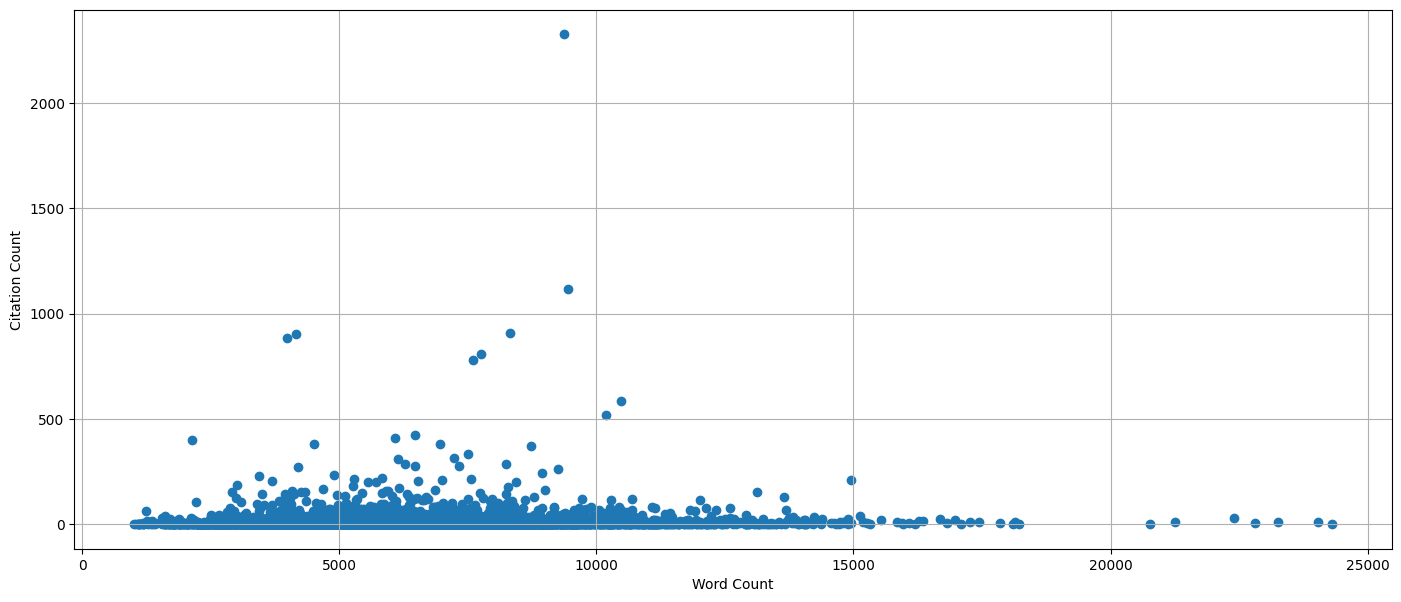

In [18]:
plt.figure(figsize=(17,7))

# plt.scatter(joined_df["word_count"], joined_df["influential_citation_count"])
plt.scatter(joined_df["word_count"], joined_df["citation_count"])
plt.ylabel("Citation Count")
plt.xlabel("Word Count")

plt.grid(True)
plt.show()



In [ ]:
um_contractions,contractions_per_1000
,uses_contractions,num_exclamation,exclamation_per_1000,
uses_exclamation,num_signposting,signposting_per_1000,uses_signposting,
num_vague_verbs,vague_verbs_per_1000,uses_vague_verbs,num_allows_to,
allows_to_per_1000,uses_allows_to,num_aim_to,aim_to_per_1000,uses_aim_to,num_we,we_per_1000
,uses_we,num_hedging,hedging_per_1000,uses_hedging,num_to_that_end,to_that_end_per_1000
,uses_to_that_end,num_chatgpt_words,chatgpt_words_per_1000,uses_chatgpt_words,num_absolute_words,
absolute_words_per_1000,uses_absolute_words,num_comparatives,comparatives_per_1000,uses_comparatives,num_passive,passive_per_1000,uses_passive

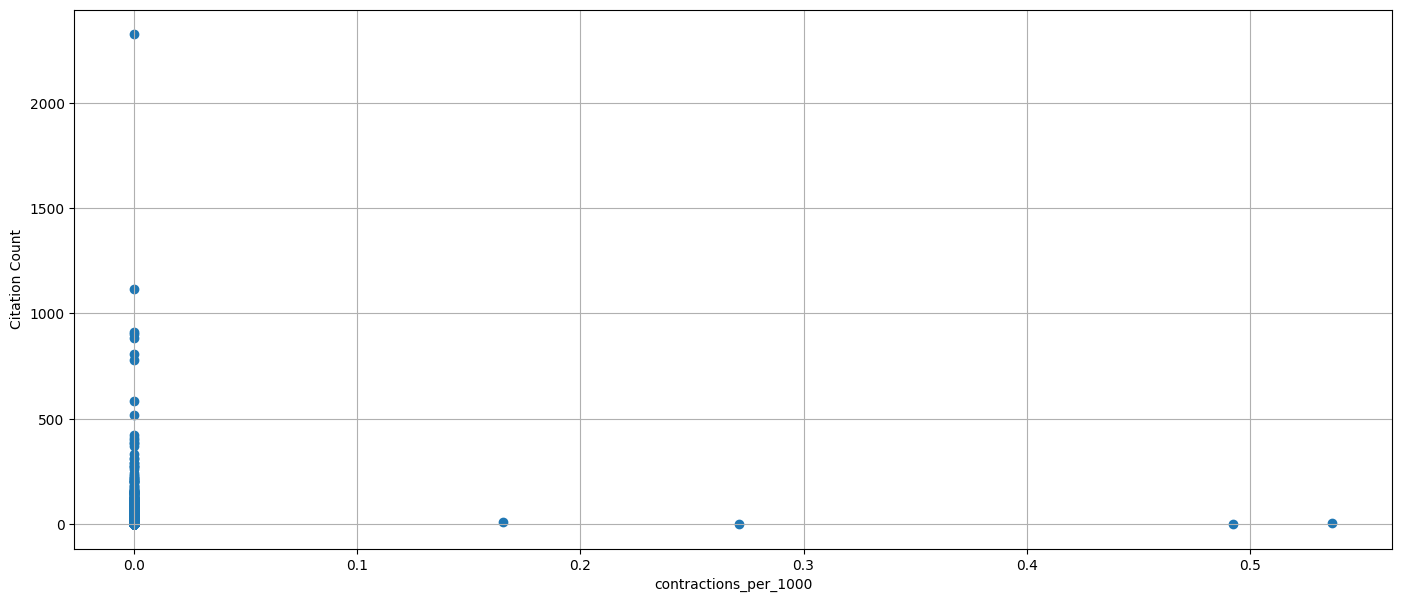

In [20]:
plt.figure(figsize=(17,7))

# plt.scatter(joined_df["word_count"], joined_df["influential_citation_count"])
plt.scatter(joined_df["contractions_per_1000"], joined_df["citation_count"])
plt.ylabel("Citation Count")
plt.xlabel("contractions_per_1000")

plt.grid(True)
plt.show()


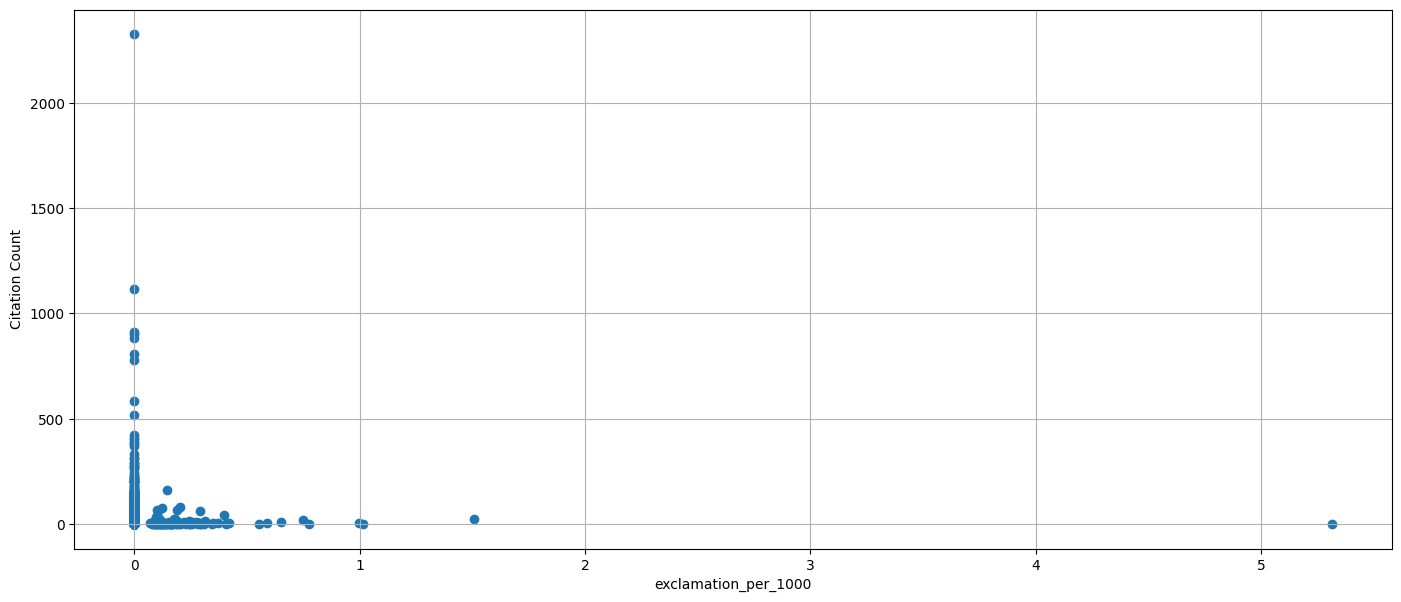

In [21]:
plt.figure(figsize=(17,7))

# plt.scatter(joined_df["word_count"], joined_df["influential_citation_count"])
plt.scatter(joined_df["exclamation_per_1000"], joined_df["citation_count"])
plt.ylabel("Citation Count")
plt.xlabel("exclamation_per_1000")

plt.grid(True)
plt.show()

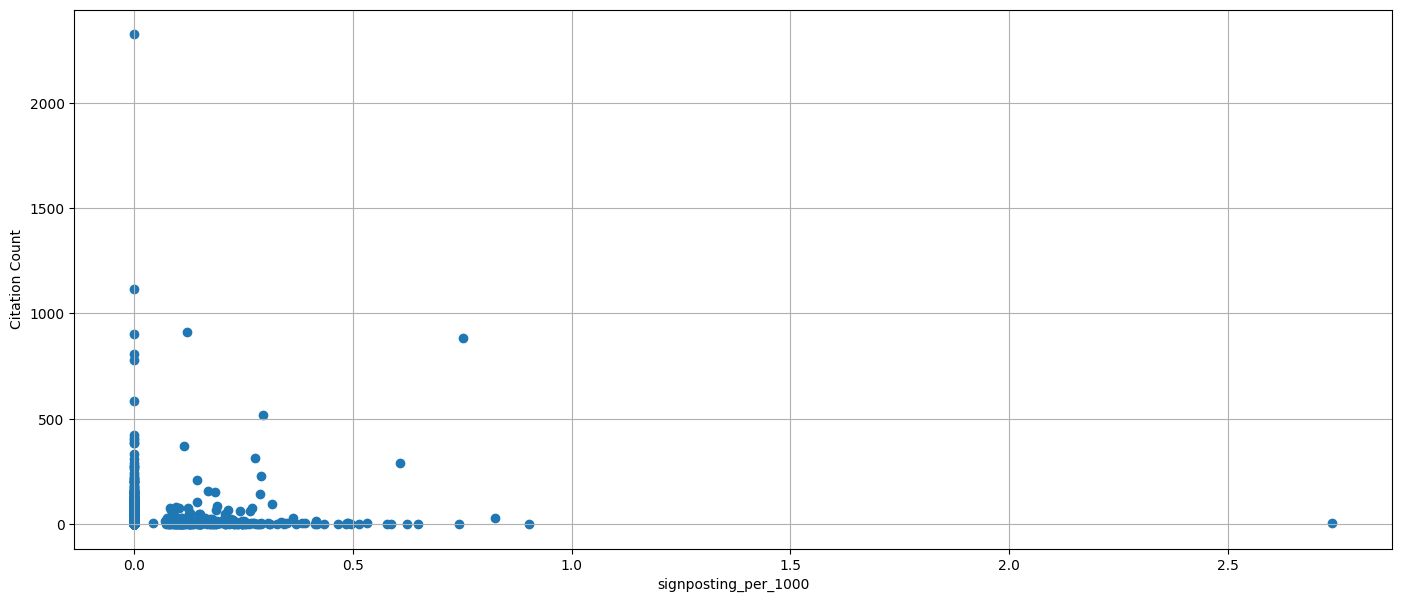

In [22]:
plt.figure(figsize=(17,7))

# plt.scatter(joined_df["word_count"], joined_df["influential_citation_count"])
plt.scatter(joined_df["signposting_per_1000"], joined_df["citation_count"])
plt.ylabel("Citation Count")
plt.xlabel("signposting_per_1000")

plt.grid(True)
plt.show()

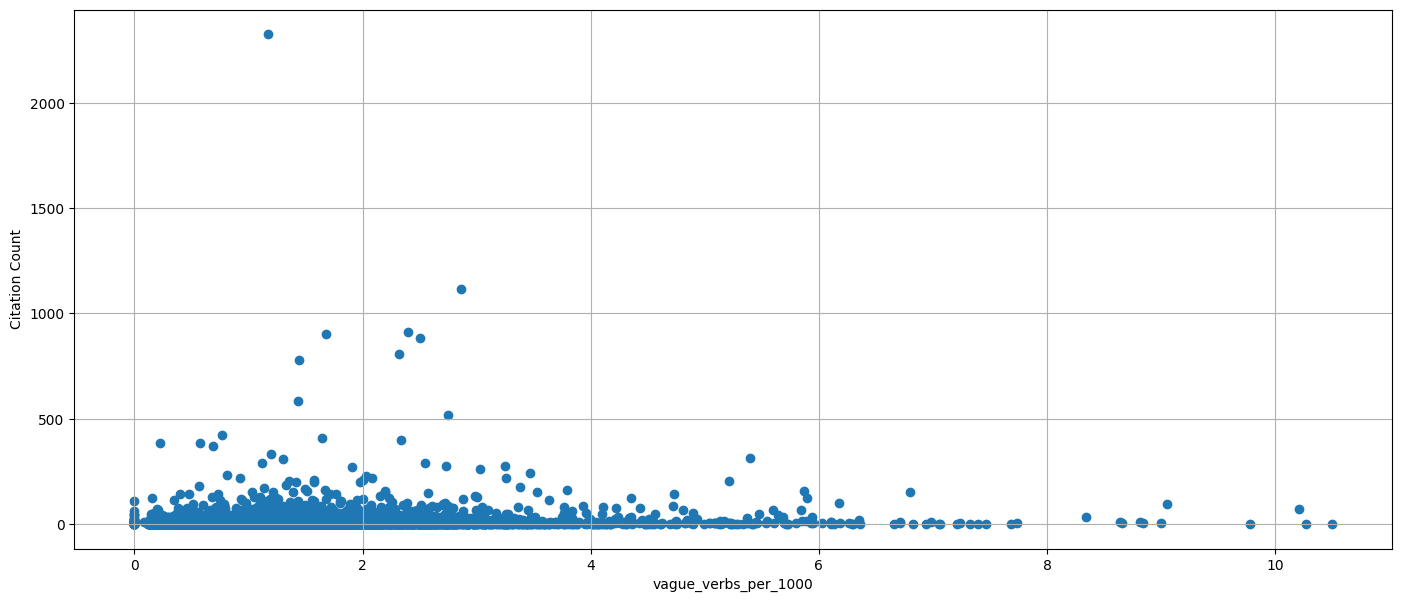

In [23]:
plt.figure(figsize=(17,7))

# plt.scatter(joined_df["word_count"], joined_df["influential_citation_count"])
plt.scatter(joined_df["vague_verbs_per_1000"], joined_df["citation_count"])
plt.ylabel("Citation Count")
plt.xlabel("vague_verbs_per_1000")

plt.grid(True)
plt.show()

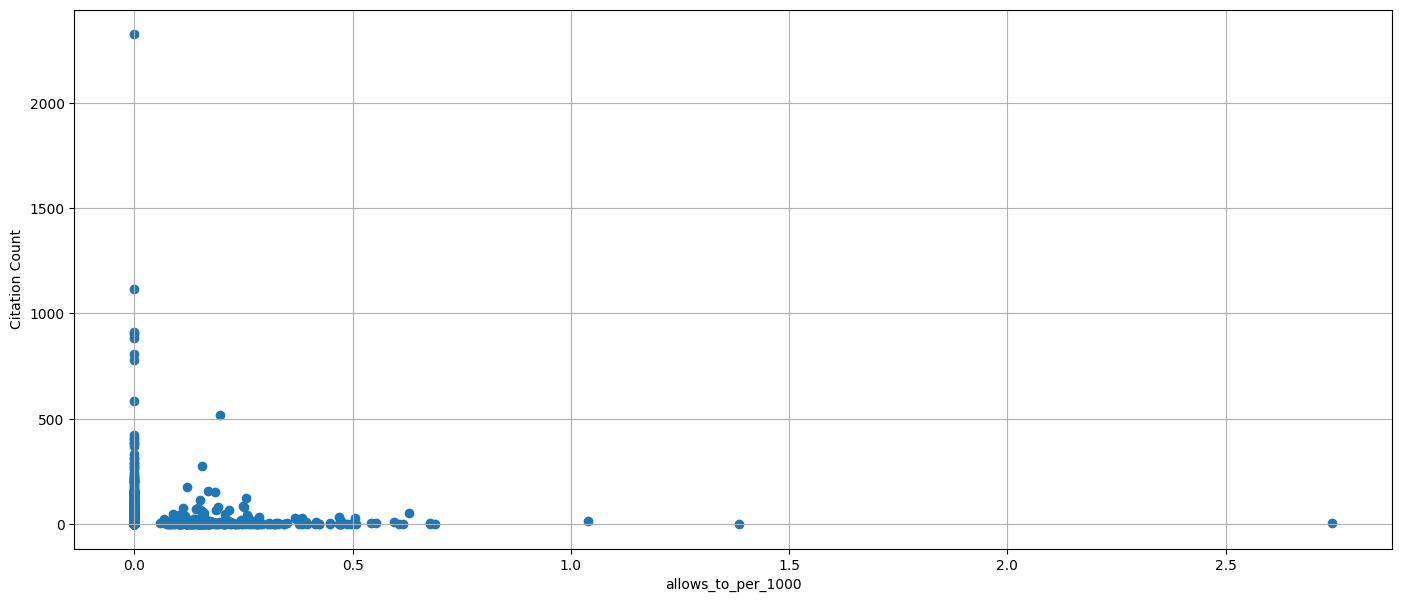

In [24]:

plt.figure(figsize=(17,7))

# plt.scatter(joined_df["word_count"], joined_df["influential_citation_count"])
plt.scatter(joined_df["allows_to_per_1000"], joined_df["citation_count"])
plt.ylabel("Citation Count")
plt.xlabel("allows_to_per_1000")

plt.grid(True)
plt.show()

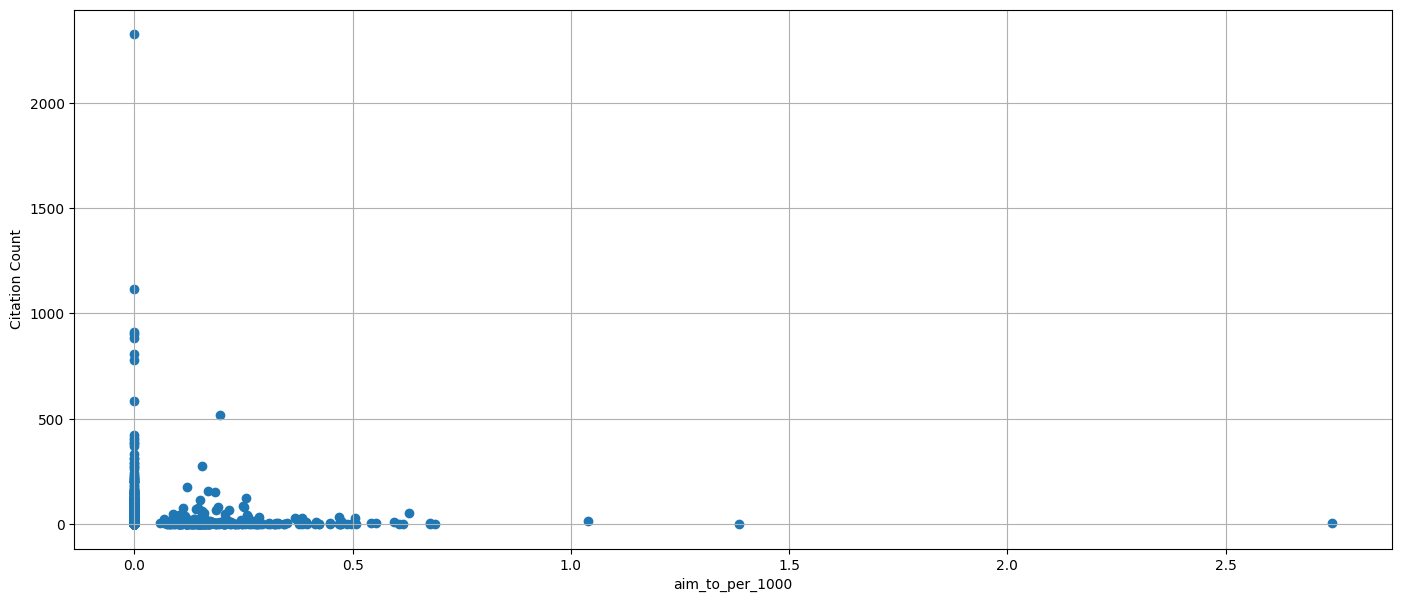

In [25]:

plt.figure(figsize=(17,7))

# plt.scatter(joined_df["word_count"], joined_df["influential_citation_count"])
plt.scatter(joined_df["allows_to_per_1000"], joined_df["citation_count"])
plt.ylabel("Citation Count")
plt.xlabel("aim_to_per_1000")

plt.grid(True)
plt.show()

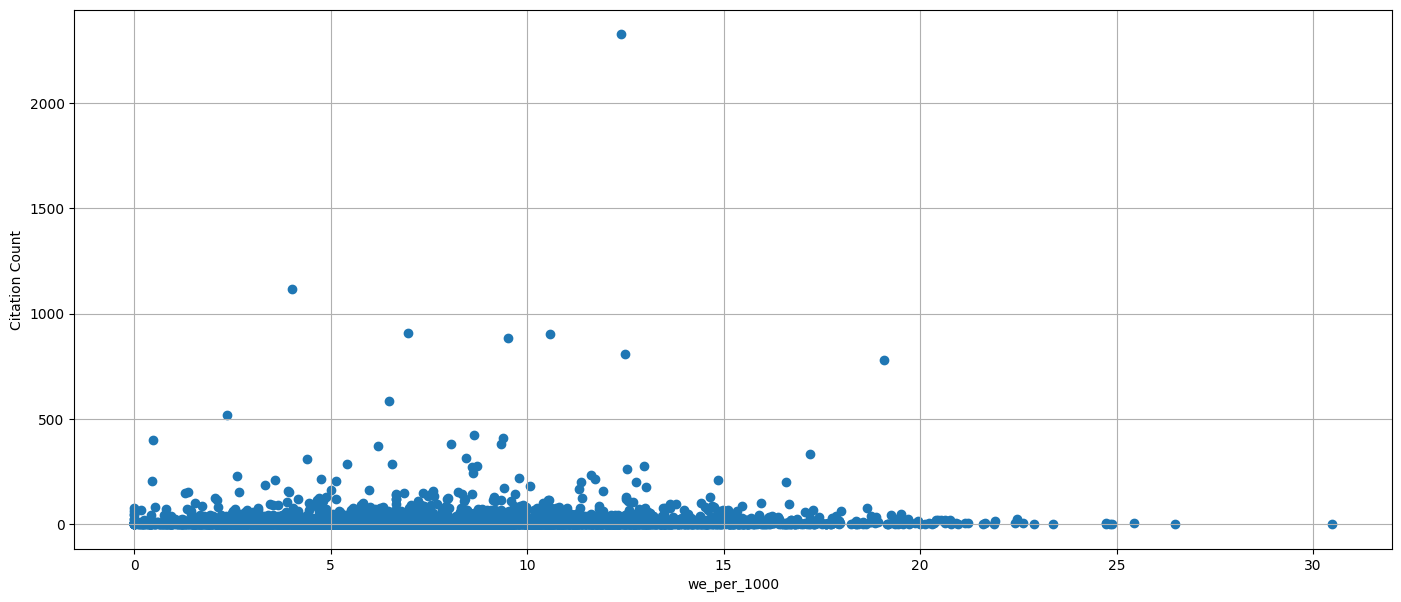

In [26]:

plt.figure(figsize=(17,7))

# plt.scatter(joined_df["word_count"], joined_df["influential_citation_count"])
plt.scatter(joined_df["we_per_1000"], joined_df["citation_count"])
plt.ylabel("Citation Count")
plt.xlabel("we_per_1000")

plt.grid(True)
plt.show()

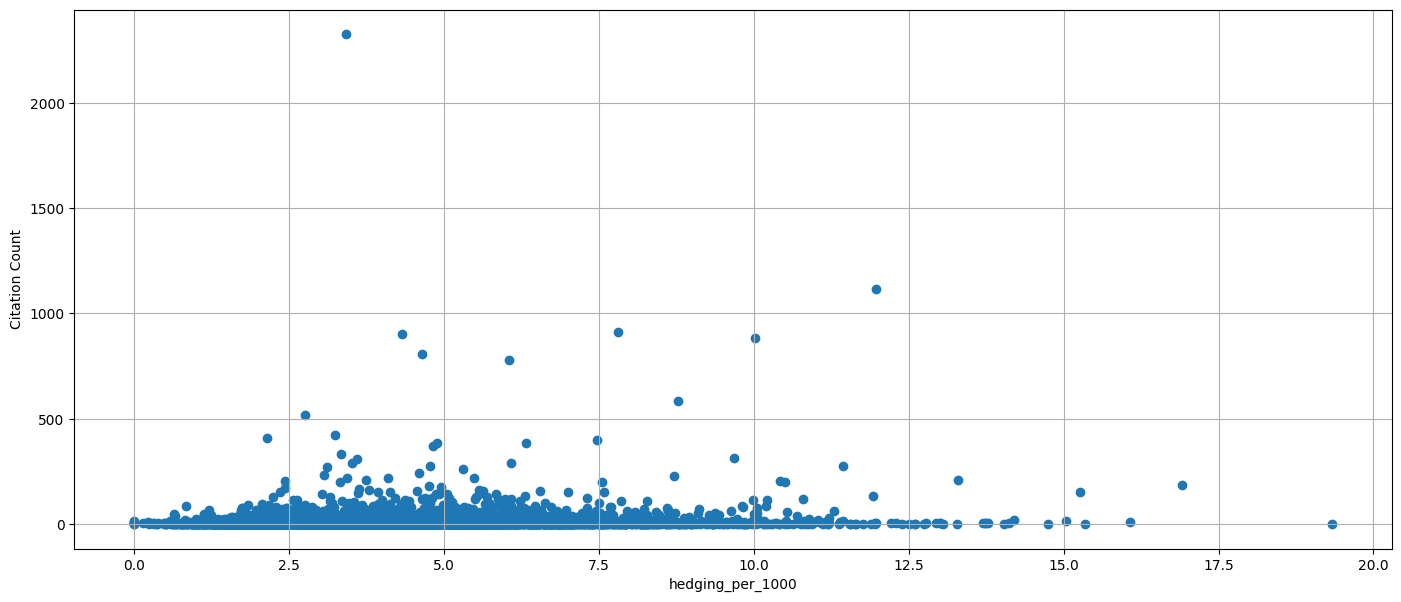

In [27]:
plt.figure(figsize=(17,7))

# plt.scatter(joined_df["word_count"], joined_df["influential_citation_count"])
plt.scatter(joined_df["hedging_per_1000"], joined_df["citation_count"])
plt.ylabel("Citation Count")
plt.xlabel("hedging_per_1000")

plt.grid(True)
plt.show()

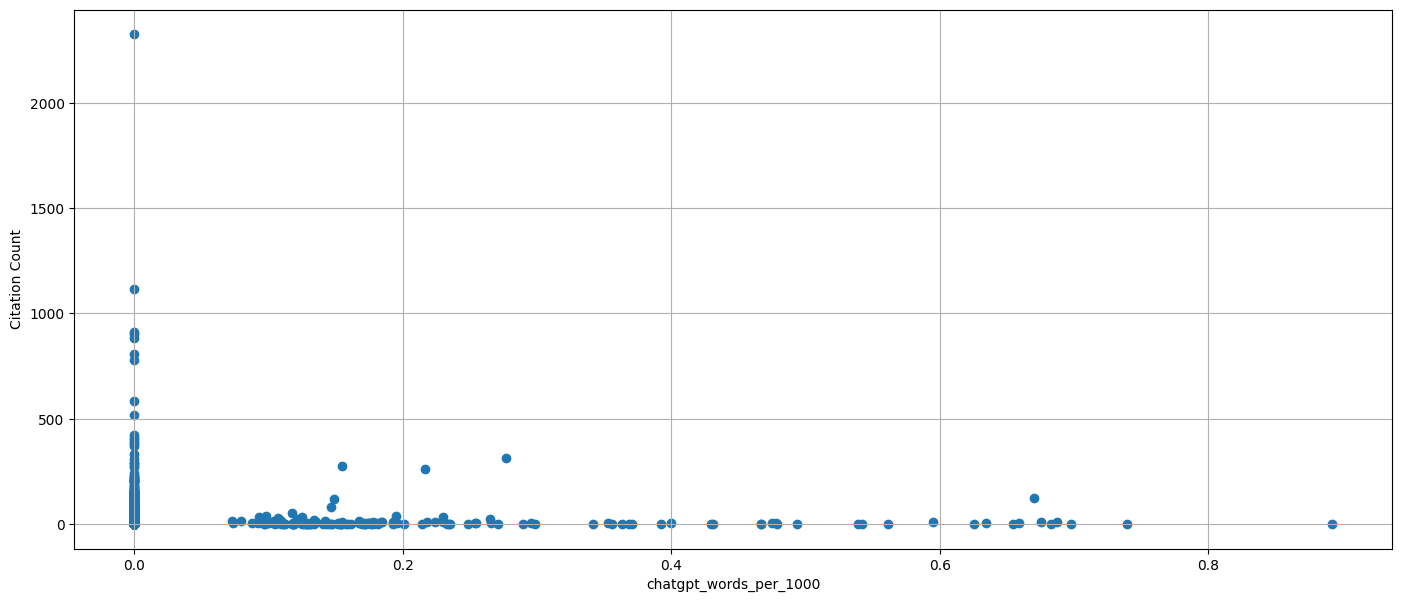

In [28]:
plt.figure(figsize=(17,7))

# plt.scatter(joined_df["word_count"], joined_df["influential_citation_count"])
plt.scatter(joined_df["chatgpt_words_per_1000"], joined_df["citation_count"])
plt.ylabel("Citation Count")
plt.xlabel("chatgpt_words_per_1000")

plt.grid(True)
plt.show()

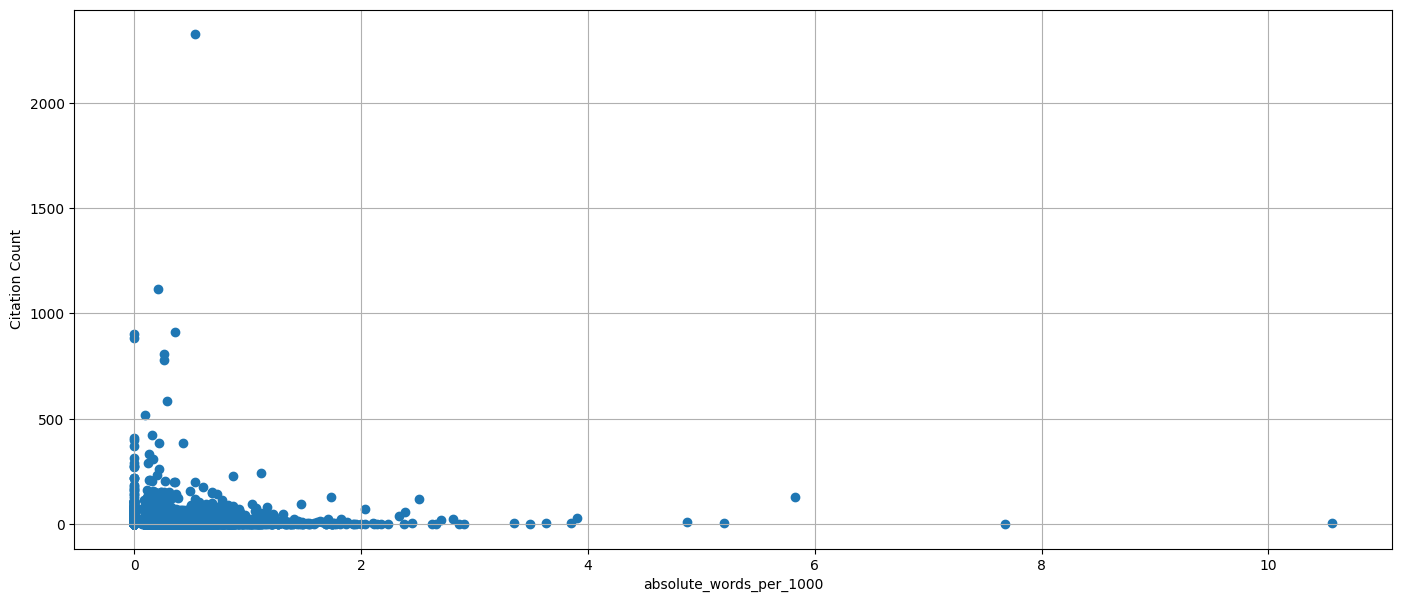

In [29]:
plt.figure(figsize=(17,7))

# plt.scatter(joined_df["word_count"], joined_df["influential_citation_count"])
plt.scatter(joined_df["absolute_words_per_1000"], joined_df["citation_count"])
plt.ylabel("Citation Count")
plt.xlabel("absolute_words_per_1000")

plt.grid(True)
plt.show()

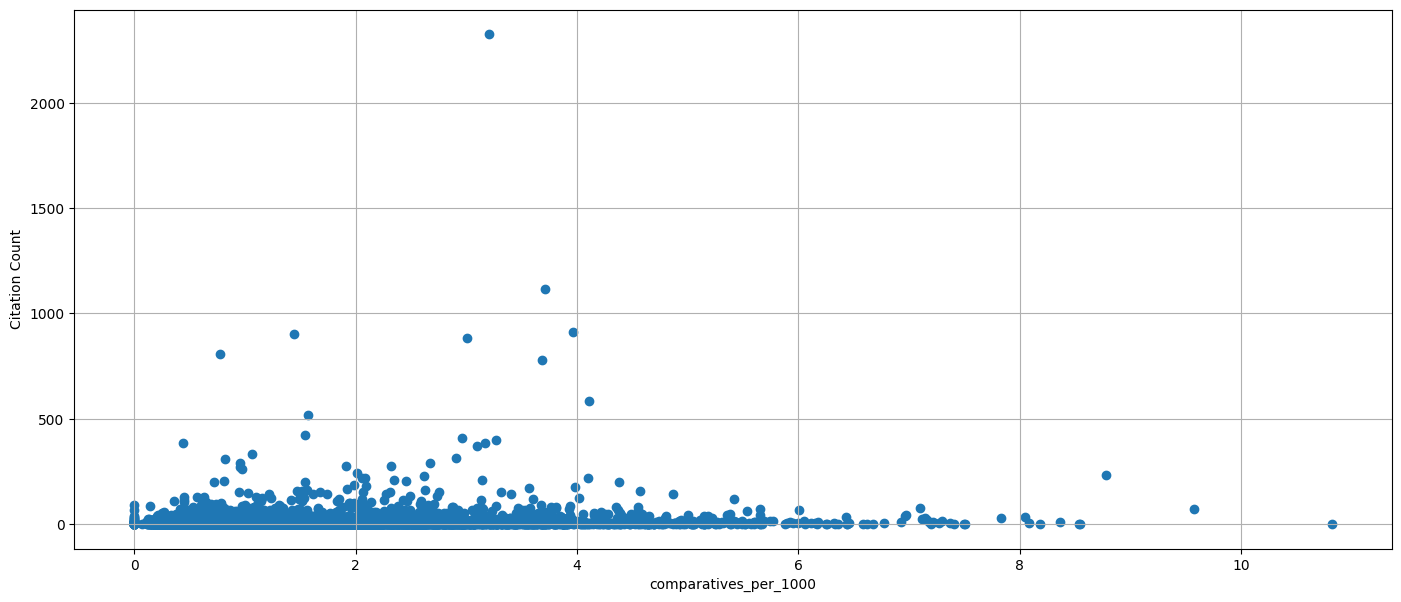

In [30]:
plt.figure(figsize=(17,7))

# plt.scatter(joined_df["word_count"], joined_df["influential_citation_count"])
plt.scatter(joined_df["comparatives_per_1000"], joined_df["citation_count"])
plt.ylabel("Citation Count")
plt.xlabel("comparatives_per_1000")

plt.grid(True)
plt.show()

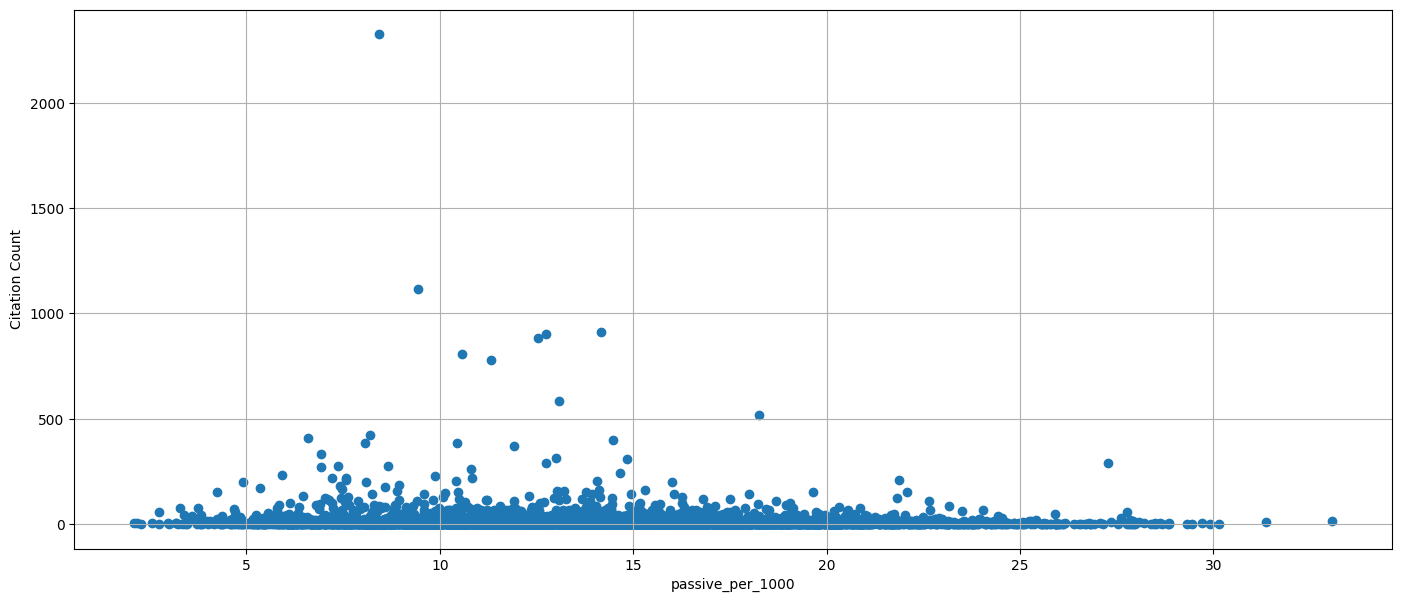

In [31]:
plt.figure(figsize=(17,7))

# plt.scatter(joined_df["word_count"], joined_df["influential_citation_count"])
plt.scatter(joined_df["passive_per_1000"], joined_df["citation_count"])
plt.ylabel("Citation Count")
plt.xlabel("passive_per_1000")

plt.grid(True)
plt.show()